#Random Forest

##¿Cómo Funciona?
Los algoritmos de bosque aleatorio tienen tres hiperparámetros principales, que deben configurarse antes del entrenamiento. Estos incluyen el tamaño del nodo, la cantidad de árboles y la cantidad de características muestreadas. A partir de ahí, el clasificador de bosque aleatorio se puede utilizar para resolver problemas de regresión o clasificación.

El algoritmo de bosque aleatorio se compone de una colección de árboles de decisión y cada árbol en el conjunto está compuesto por una muestra de datos extraída de un conjunto de entrenamiento con reemplazo, llamado bootstrapping. De esa muestra de entrenamiento, un tercio de ella se reserva como datos de prueba, lo que se conoce como la muestra fuera de bolsa (oob), a la que volveremos más adelante. Luego, se inyecta otra instancia de aleatoriedad mediante el embolsado de características, lo que agrega más diversidad al conjunto de datos y reduce la correlación entre los árboles de decisión. Dependiendo del tipo de problema, la determinación de la predicción variará. Para una tarea de regresión, se promediarán los árboles de decisión individuales, y para una tarea de clasificación, el voto mayoritario, es decir, la variable categórica más frecuente, arrojará la clase prevista. Finalmente, la muestra fuera de la bolsa (oob) se utiliza para la validación cruzada, finalizando esa predicción.

## Ventajas y desafíos del bosque aleatorio
El algoritmo de bosque aleatorio presenta una cantidad de ventajas y desafíos clave cuando se utiliza para problemas de clasificación o regresión. Por ejemplo:

###Beneficios principales
#####Menor riesgo de sobreajuste: Los árboles de decisión corren el riesgo de presentar sobreajustes, ya que tienden a ajustar estrechamente a todas las muestras dentro de los datos de entrenamiento. Sin embargo, cuando hay una gran cantidad de árboles de decisión en un bosque aleatorio, el clasificador no sobreajustará el modelo, ya que el promedio de árboles no correlacionados reduce la varianza general y el error de predicción.
#####Proporciona flexibilidad: Dado que el bosque aleatorio puede manejar tareas de regresión y clasificación con un alto grado de precisión, es un método popular entre los científicos de datos. El embolsado de características también convierte al clasificador de bosque aleatorio en una herramienta eficaz para estimar los valores faltantes, ya que mantiene la precisión cuando falta una parte de los datos.
######Facilidad para determinar la importancia de las características: El bosque aleatorio facilita la evaluación de la importancia, o la contribución, de las variables al modelo. Hay algunas formas de evaluar la importancia de las características. La importancia de Gini y la disminución media de la impureza (MDI) se utilizan generalmente para medir cuánto disminuye la precisión del modelo cuando se excluye una variable dada. Sin embargo, la importancia de la permutación, también conocida como precisión de disminución media (MDA), es otra medida de importancia. MDA identifica la disminución promedio de la precisión mediante la permutación aleatoria de los valores de las características en muestras de OOB.
###Principales desafíos
##### Proceso que requiere mucho tiempo: Dado que los algoritmos de bosque aleatorio pueden manejar grandes conjuntos de datos, pueden proporcionar predicciones más precisas, pero pueden ser lentos para procesar los datos, ya que están calculando datos para cada árbol de decisión individual.
#####Requiere más recursos: Dado que los bosques aleatorios procesan conjuntos de datos más grandes, necesitarán más recursos para almacenar esos datos.
#####Mayor complejidad: La predicción de un único árbol de decisión es más fácil de interpretar que la de un bosque de ellos.

#CODE SECTION

Este bloque de código carga el archivo `ingresos.csv` en un DataFrame de pandas llamado `personas`. Luego, imprime cinco muestras aleatorias del DataFrame, cada una con dos tercios de los datos originales, lo que es útil para explorar la distribución de los datos o para la validación cruzada si se usaran estas muestras de forma independiente.

In [3]:
import pandas as pd

personas = pd.read_csv("ingresos.csv")

print(personas.sample(frac=2/3, replace=True))
print(personas.sample(frac=2/3, replace=True))
print(personas.sample(frac=2/3, replace=True))
print(personas.sample(frac=2/3, replace=True))
print(personas.sample(frac=2/3, replace=True))

    edad  estudio  genero  tipo_trabajo  horas  ingreso
20    58        4       1             1     40        0
74    29        9       1             1     45        0
13    58        9       0             0     40        0
43    49       10       1             0     44        1
7     42        9       1             0     40        1
..   ...      ...     ...           ...    ...      ...
95    32       13       1             0     55        1
82    49        9       1             0     40        0
52    35        9       1             1     60        0
49    71        9       1             0     45        1
10    49        3       0             0     20        0

[67 rows x 6 columns]
    edad  estudio  genero  tipo_trabajo  horas  ingreso
68    58       13       1             0     40        0
33    30        6       1             0     55        0
79    33        9       0             1     55        0
7     42        9       1             0     40        1
4     23        4       1

Esta celda demuestra el uso de la función `sample` del módulo `random` para seleccionar aleatoriamente un número específico de elementos de una secuencia. En este caso, se toman 3 nombres de columnas del DataFrame `personas` (excluyendo la última columna que es la variable objetivo 'ingreso').

In [7]:
from random import sample

print(personas.columns[:-1], "\n")
print(sample(list(personas.columns[:-1]), 3))

Index(['edad', 'estudio', 'genero', 'tipo_trabajo', 'horas'], dtype='object') 

['estudio', 'edad', 'genero']


Aquí se entrena un modelo de clasificación Random Forest (`RandomForestClassifier`) con 100 árboles. Se configura para usar el criterio Gini, `max_features='sqrt'` para seleccionar un subconjunto de características en cada división, y `bootstrap=True` con `max_samples=2/3` para el muestreo de los datos de entrenamiento. Se calculan y muestran la predicción para un nuevo dato, la precisión del modelo en los datos de entrenamiento y el 'out-of-bag score' (oob_score), que es una estimación de la precisión del modelo en datos no vistos.

In [8]:
from sklearn.ensemble import RandomForestClassifier

bosque = RandomForestClassifier(n_estimators=100,
                               criterion="gini",
                               max_features="sqrt",
                               bootstrap=True,
                               max_samples=2/3,
                               oob_score=True)

bosque.fit(personas[personas.columns[:-1]].values, personas["ingreso"].values)

print(bosque.predict([[50, 16, 1, 1, 40]]))
print(bosque.score(personas[personas.columns[:-1]].values, personas["ingreso"].values))
print(bosque.oob_score_)

[1]
0.99
0.75


Este código visualiza los árboles de decisión individuales que componen el modelo `bosque` (Random Forest). Itera sobre cada árbol en el bosque y usa `tree.plot_tree` para dibujar la estructura del árbol. La función `feature_names` asigna etiquetas a las características para una mejor interpretación de cada nodo del árbol. Se utiliza `plt.show()` para mostrar cada gráfico de árbol.

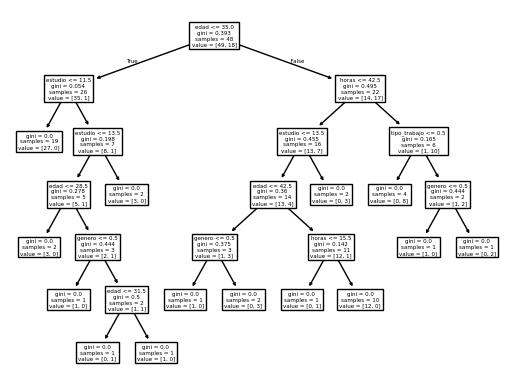

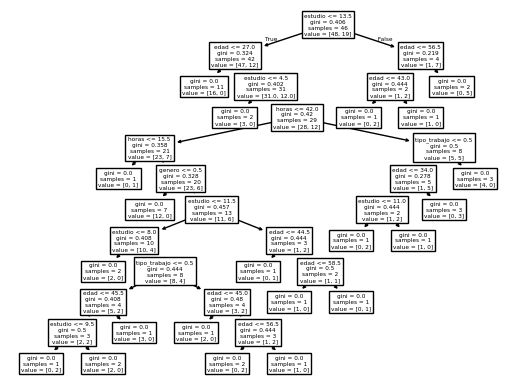

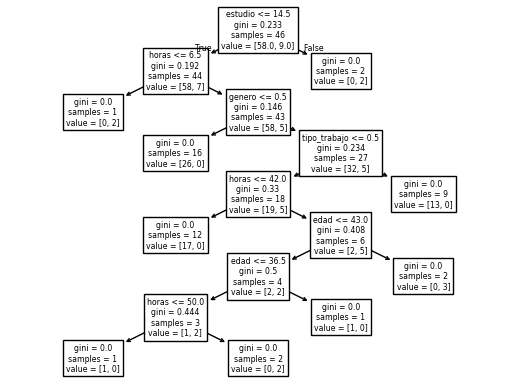

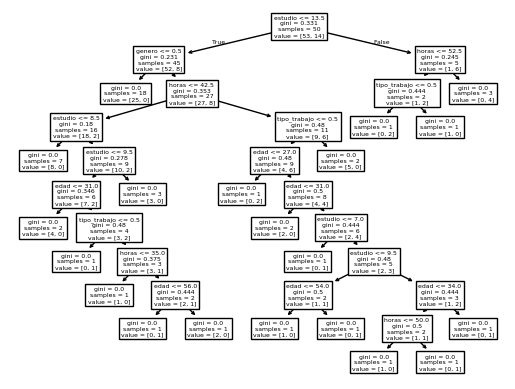

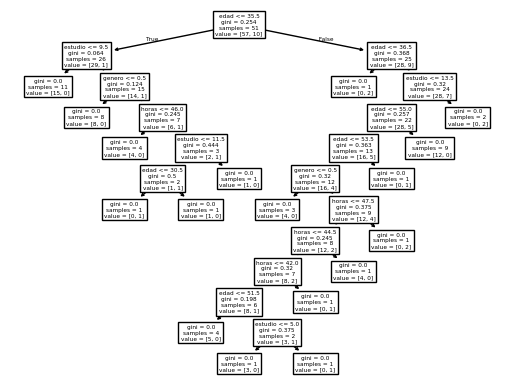

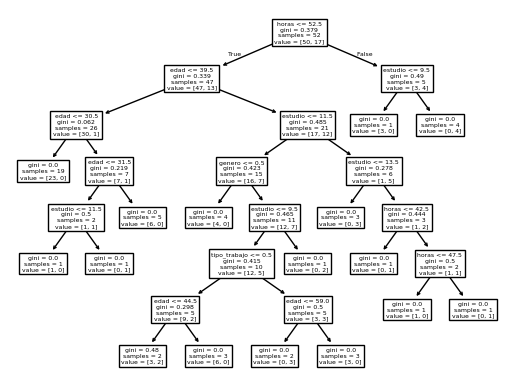

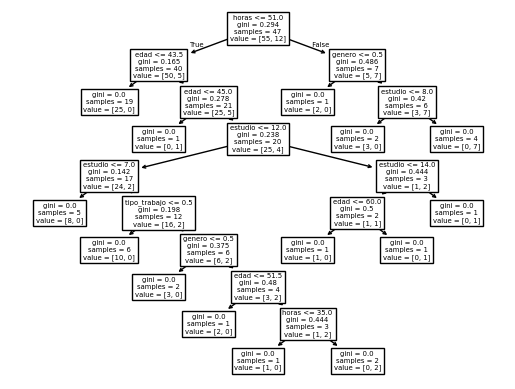

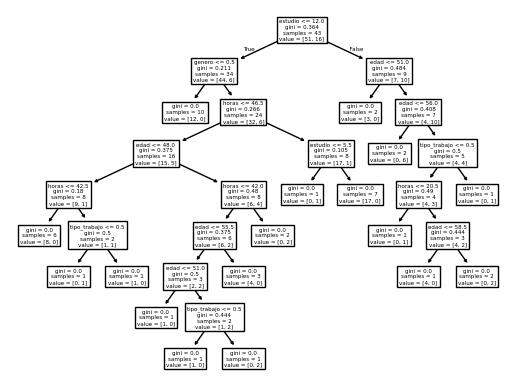

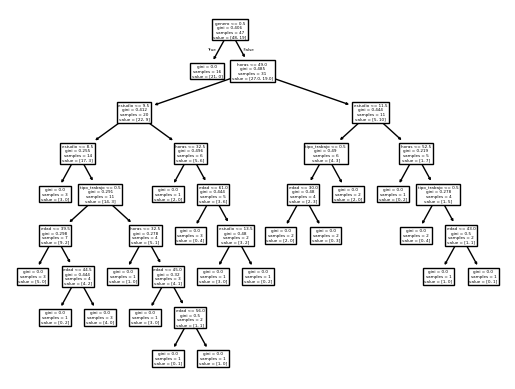

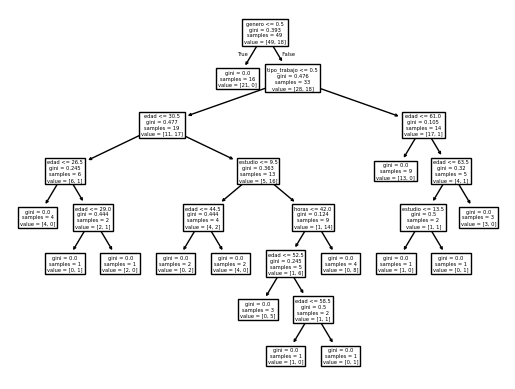

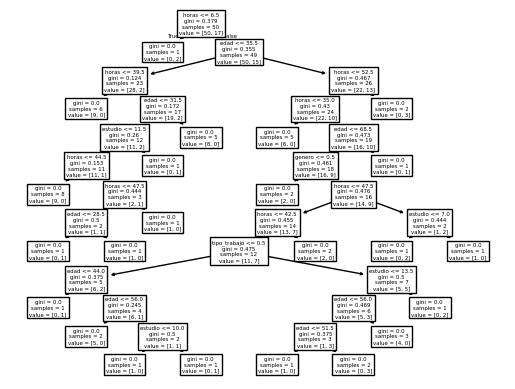

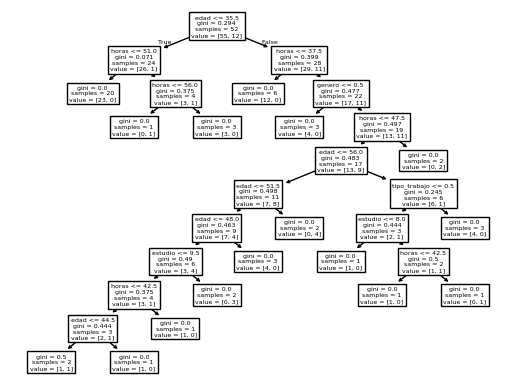

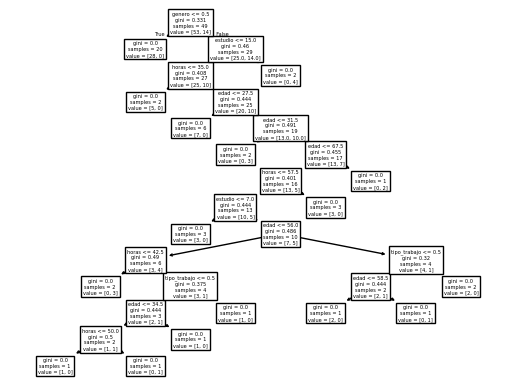

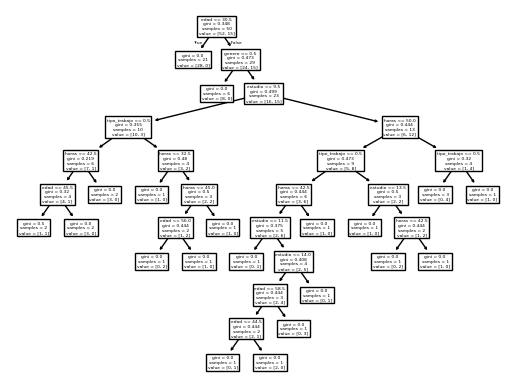

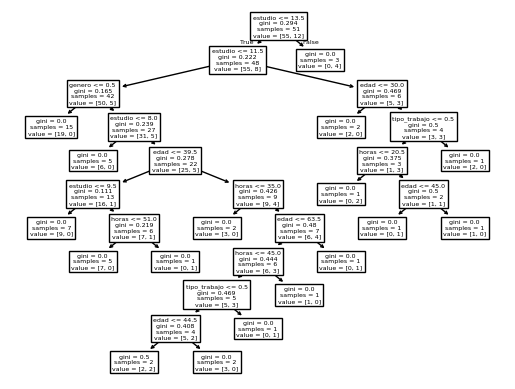

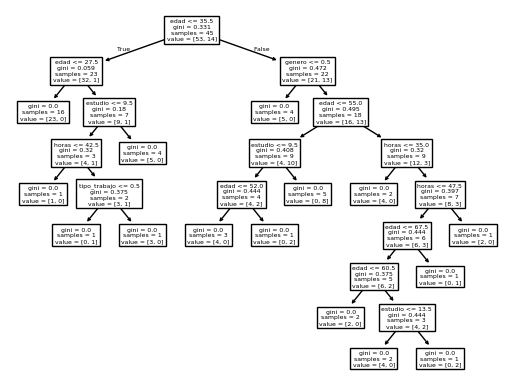

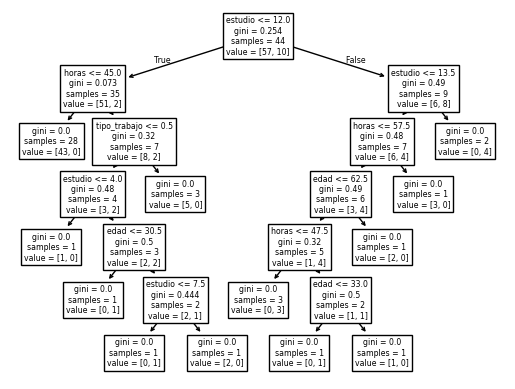

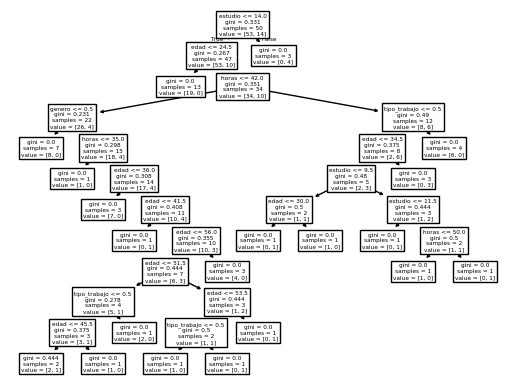

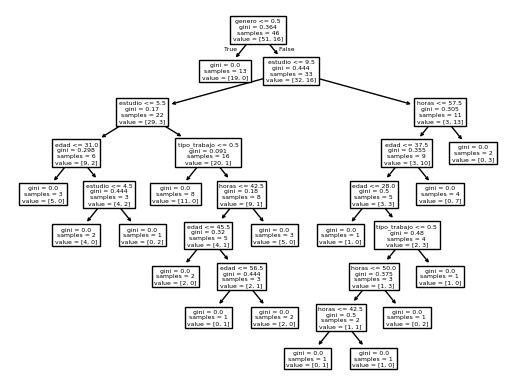

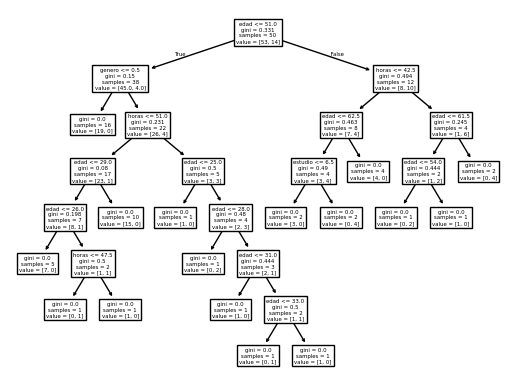

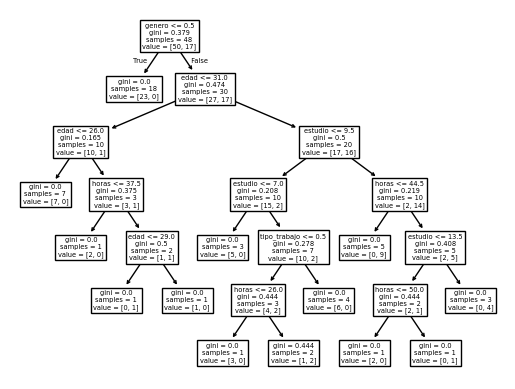

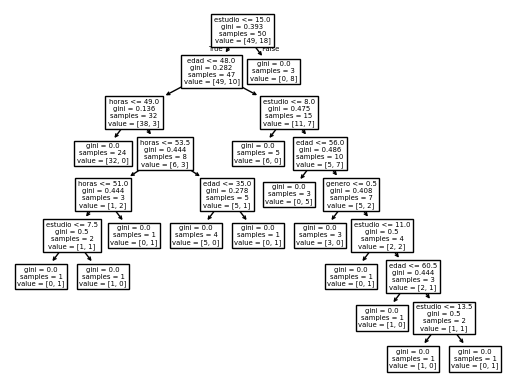

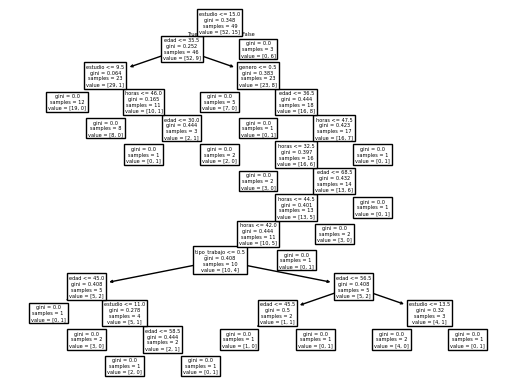

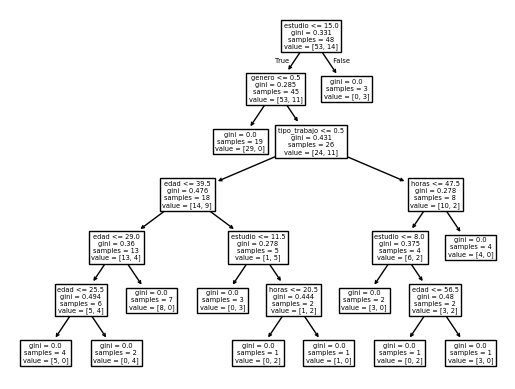

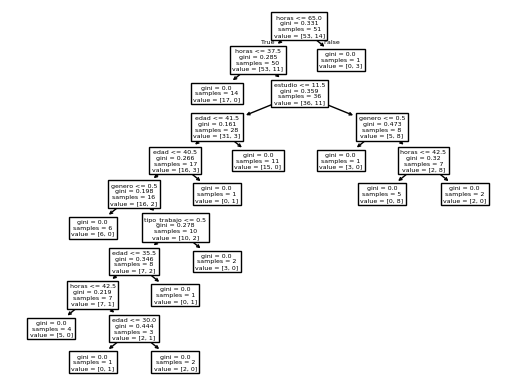

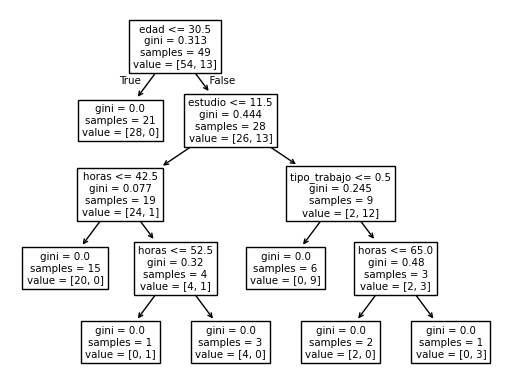

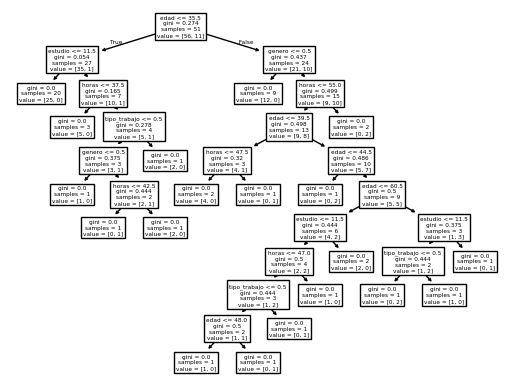

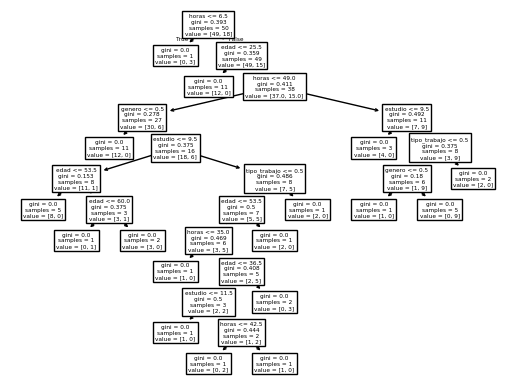

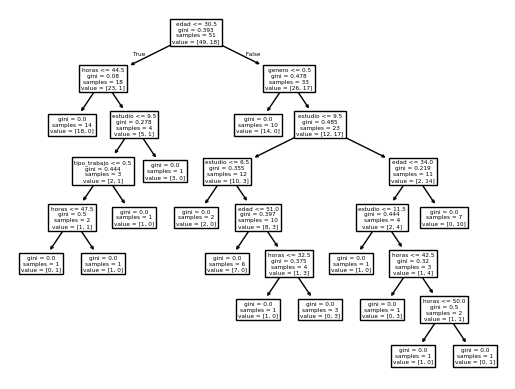

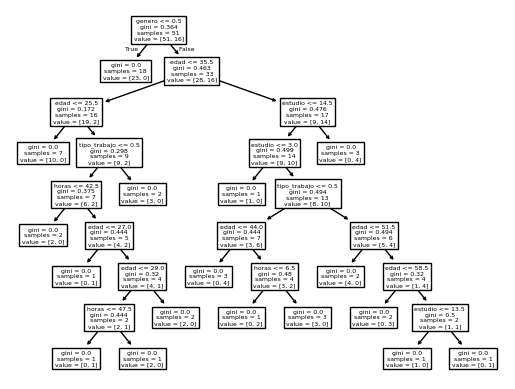

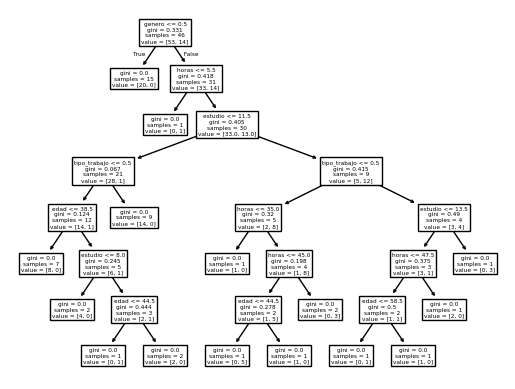

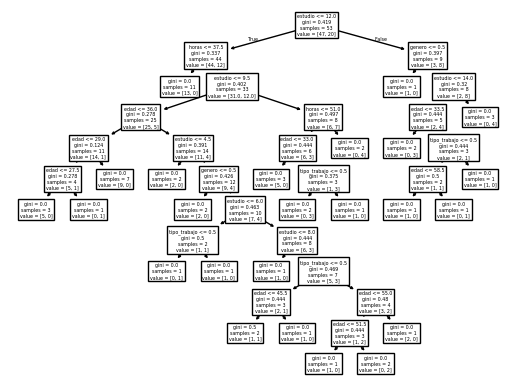

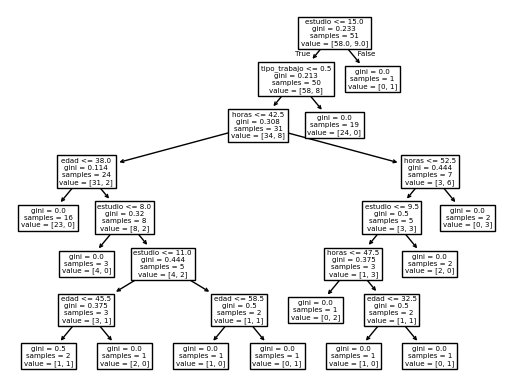

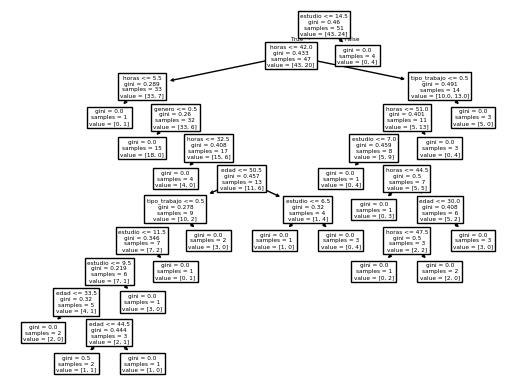

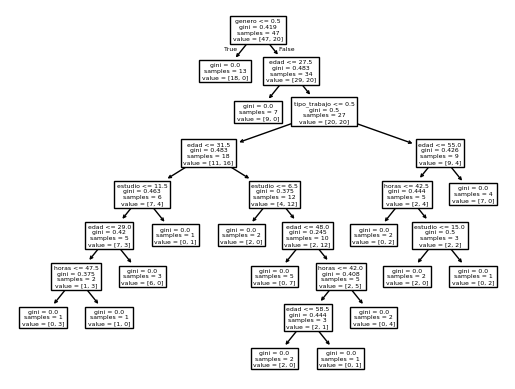

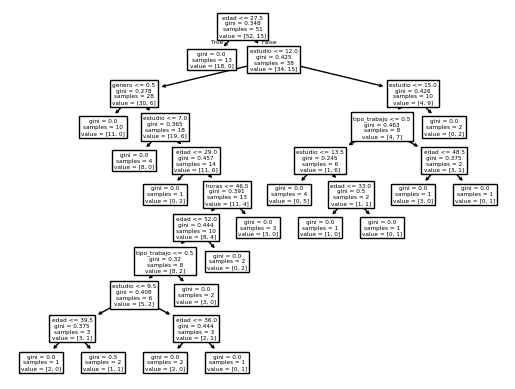

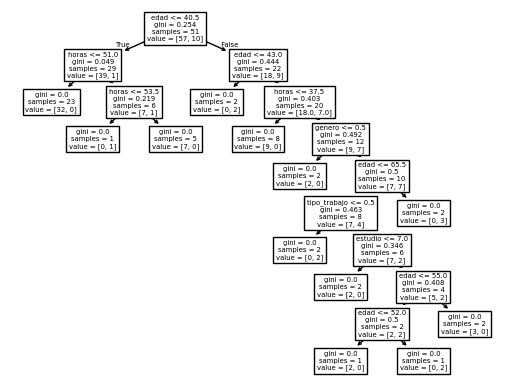

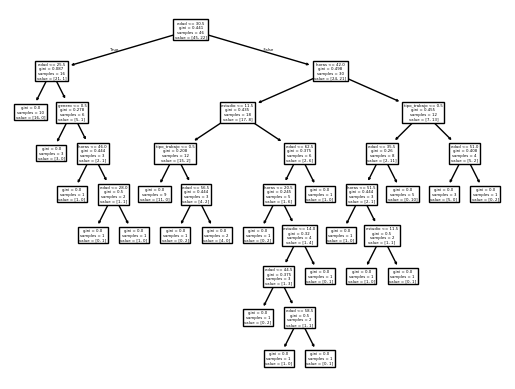

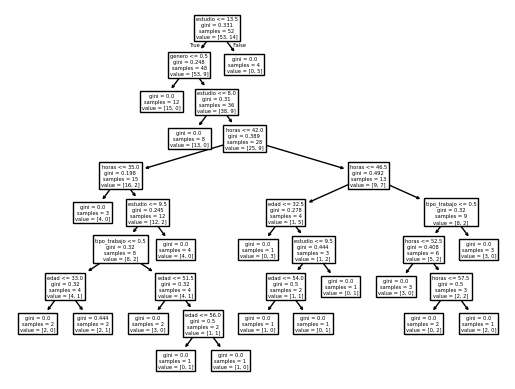

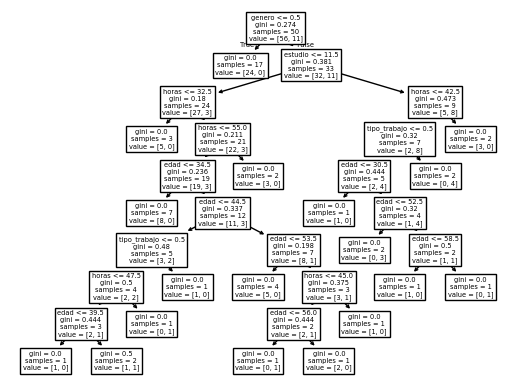

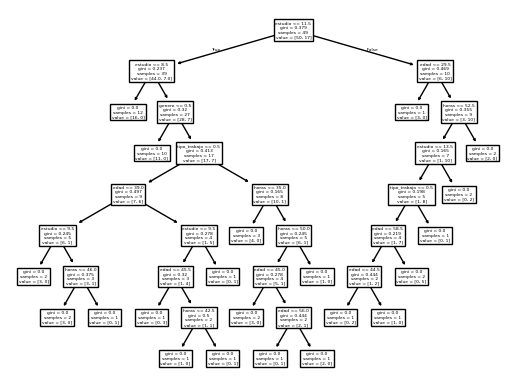

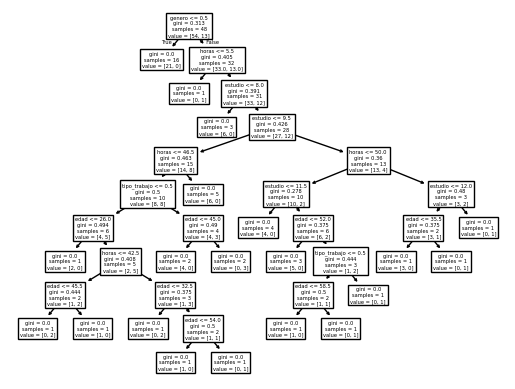

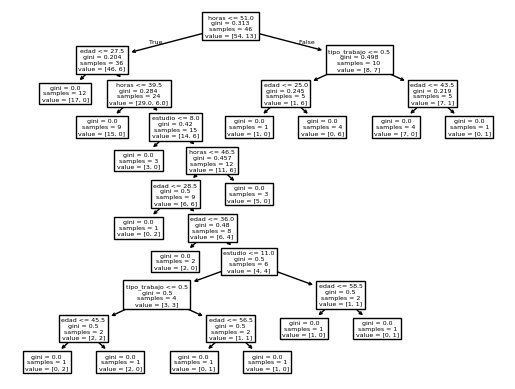

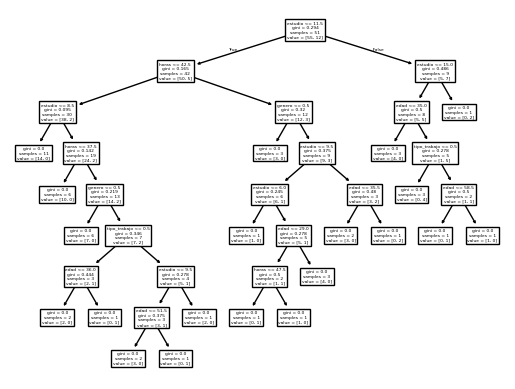

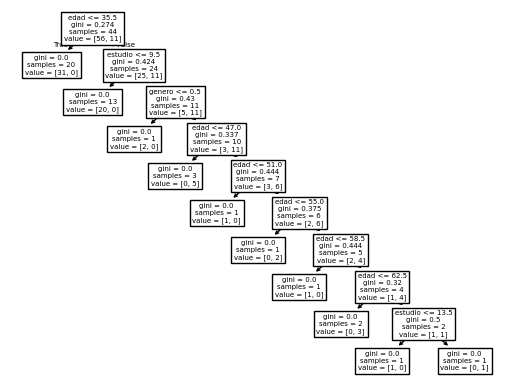

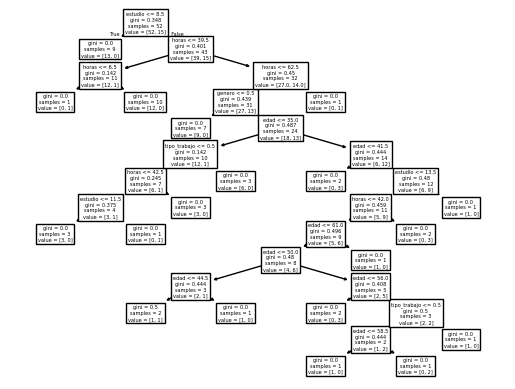

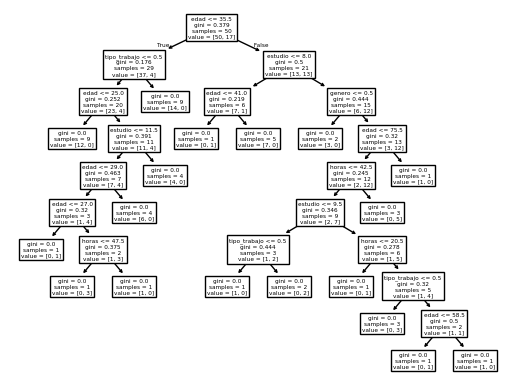

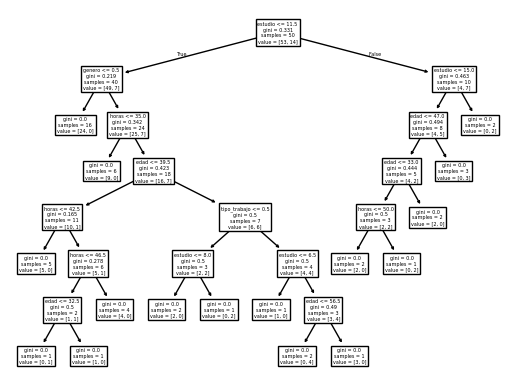

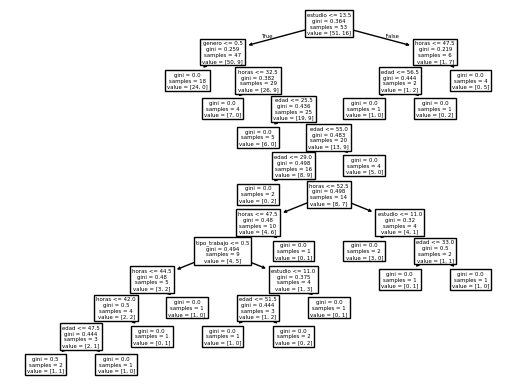

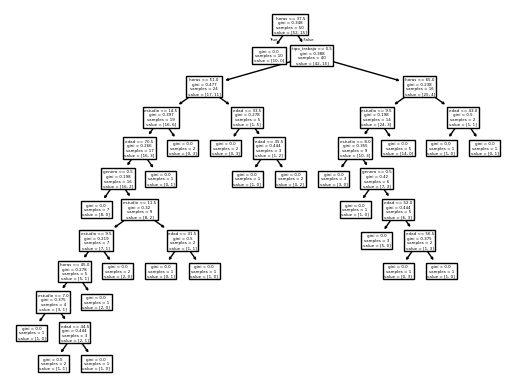

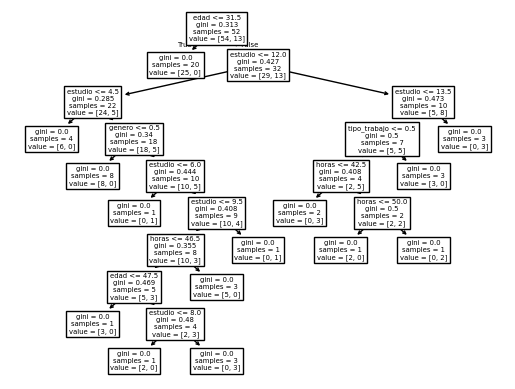

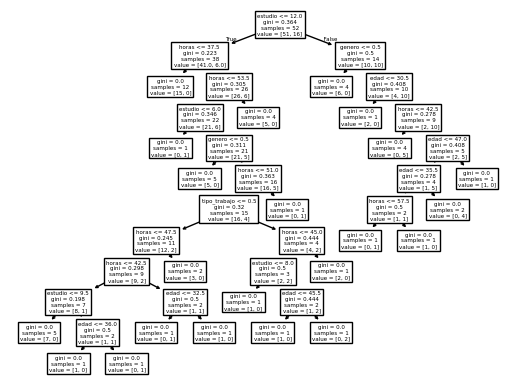

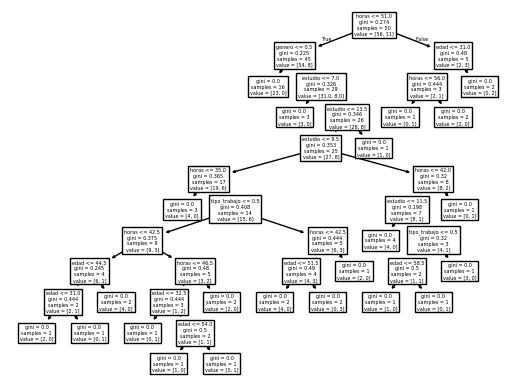

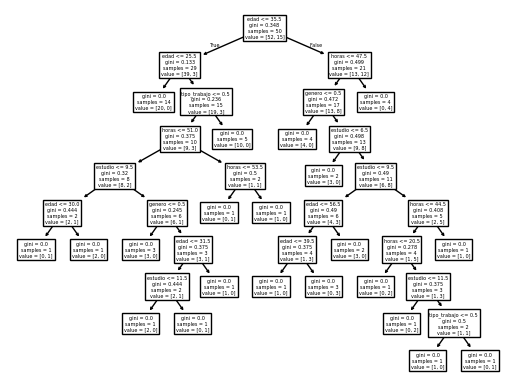

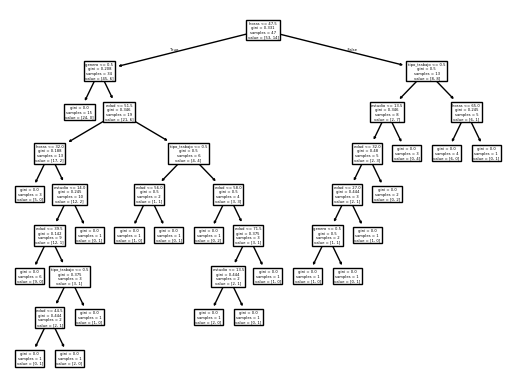

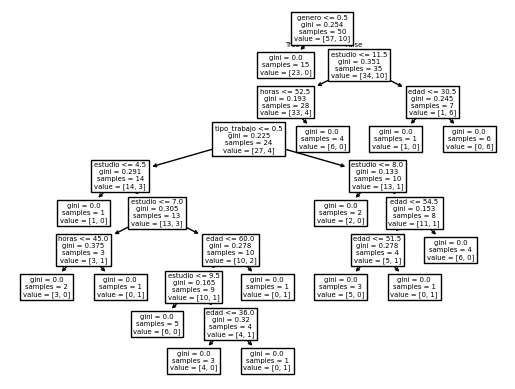

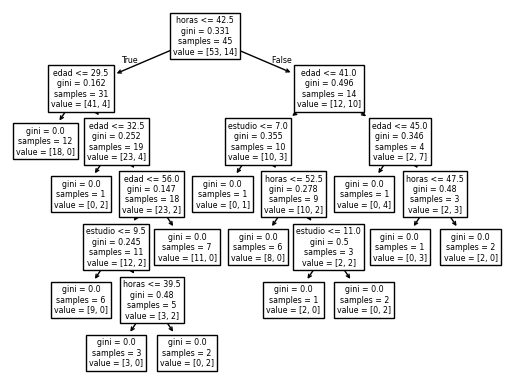

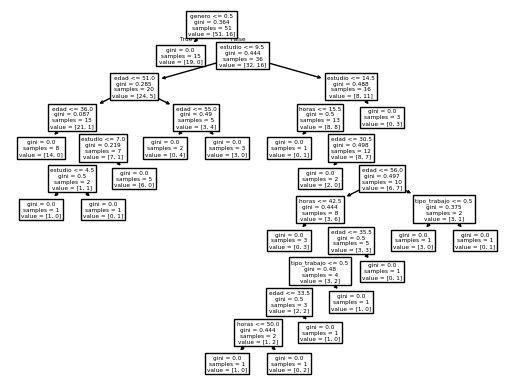

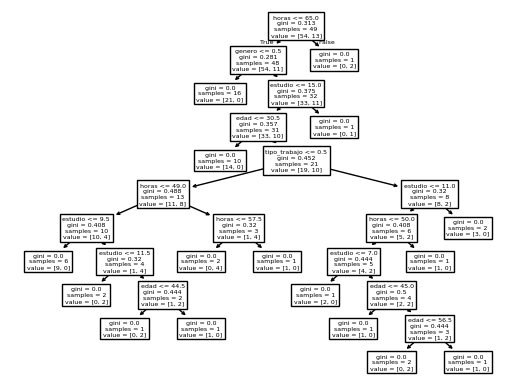

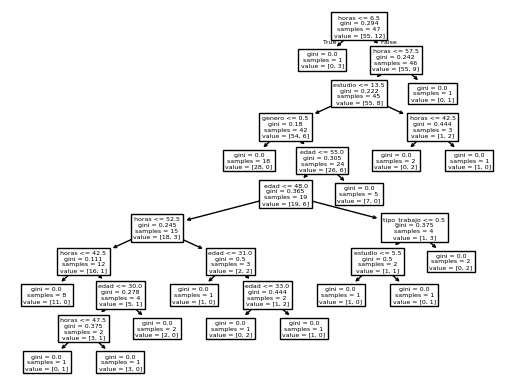

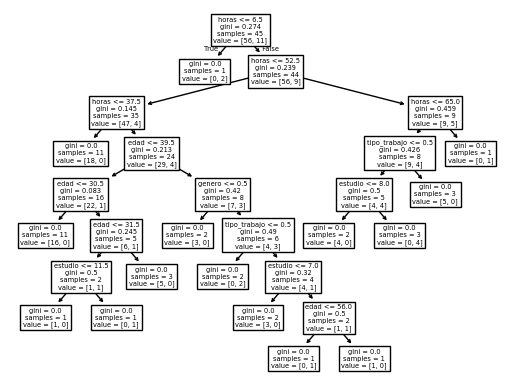

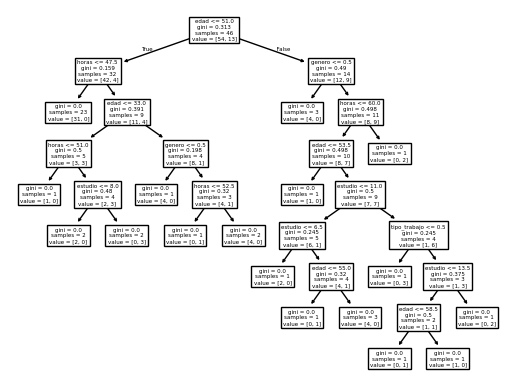

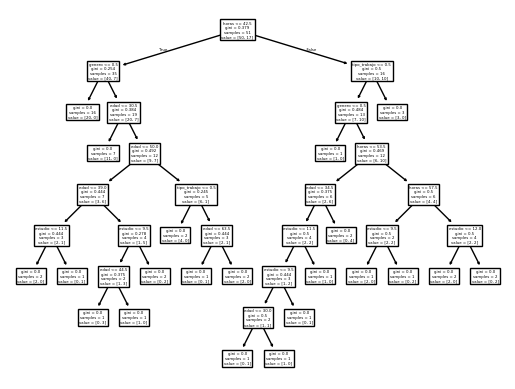

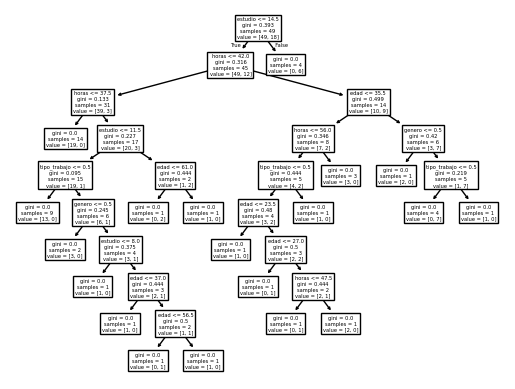

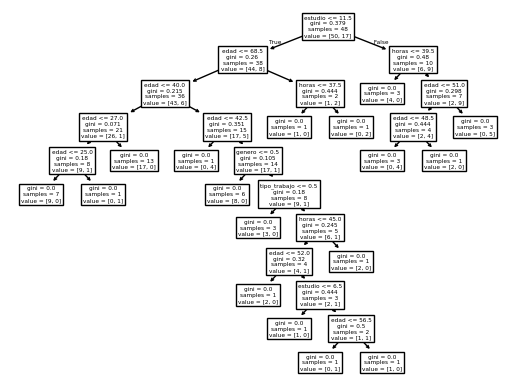

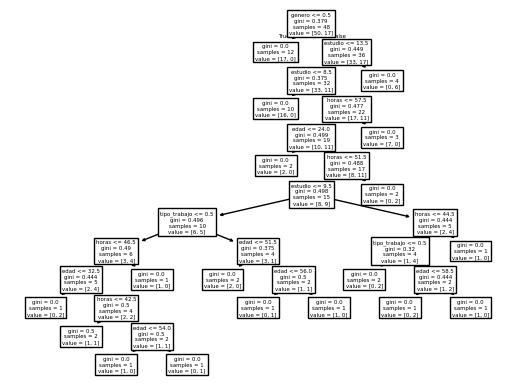

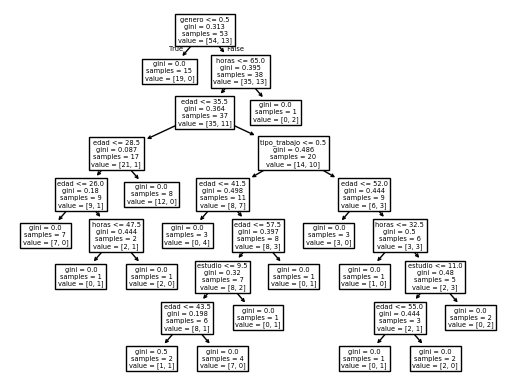

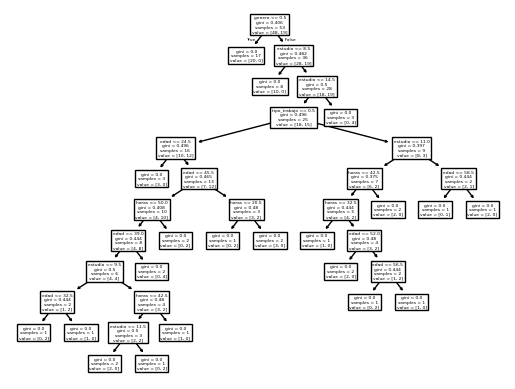

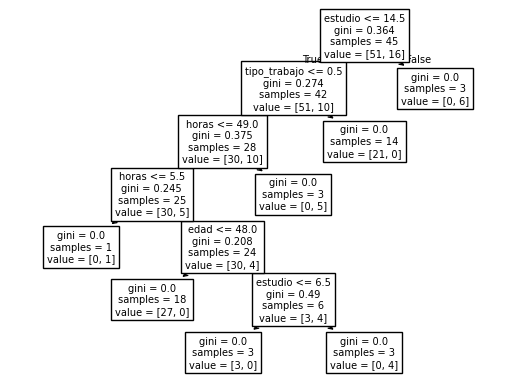

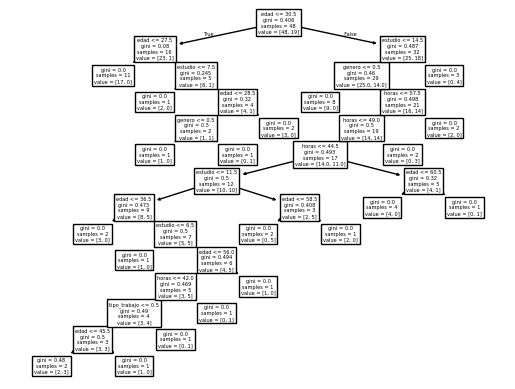

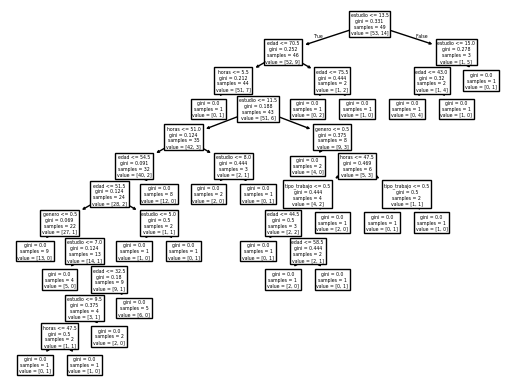

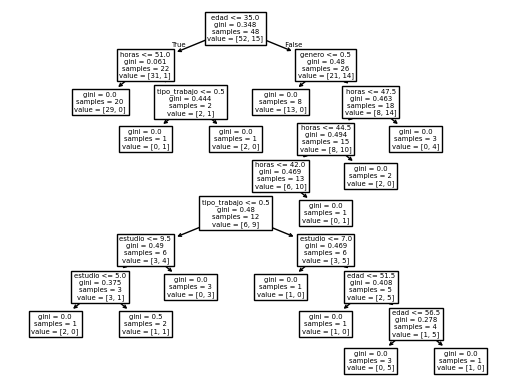

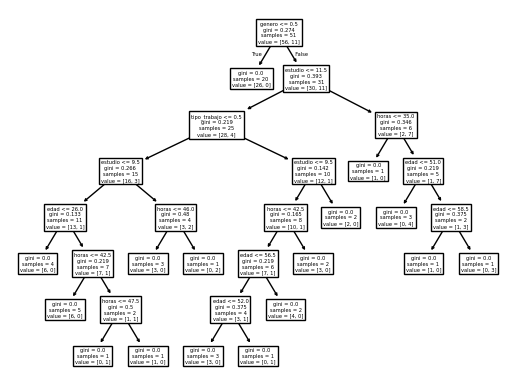

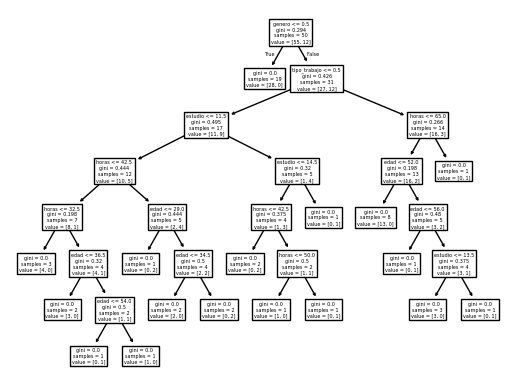

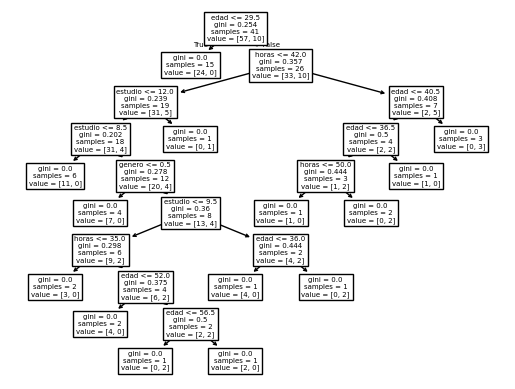

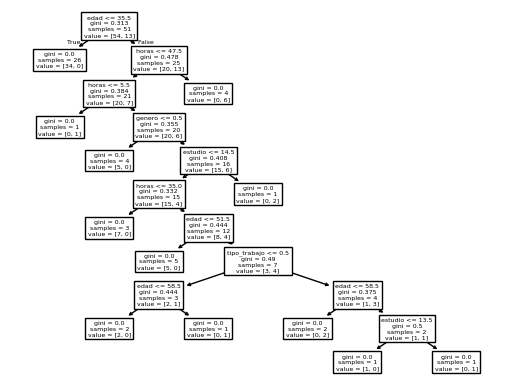

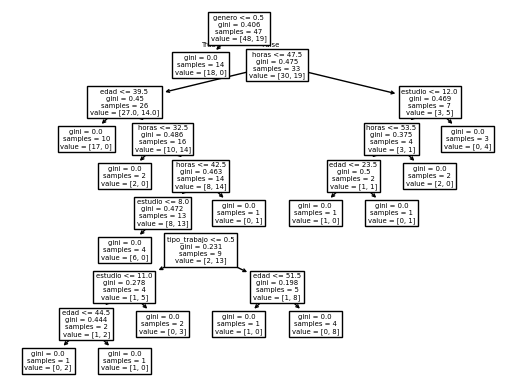

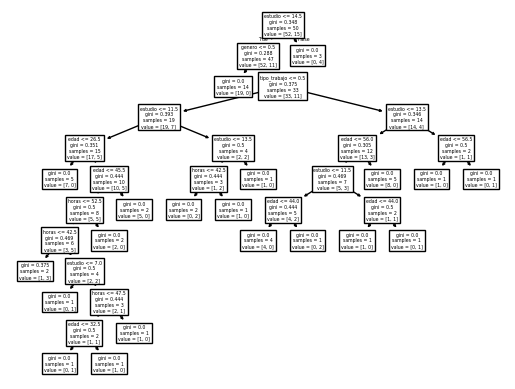

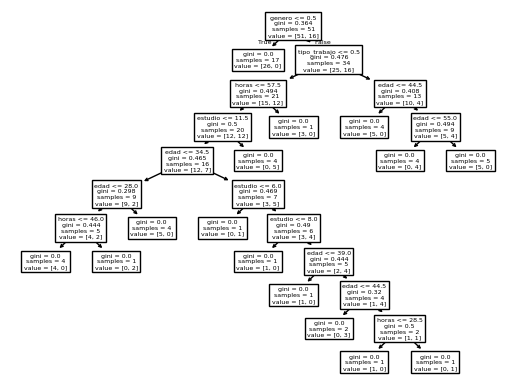

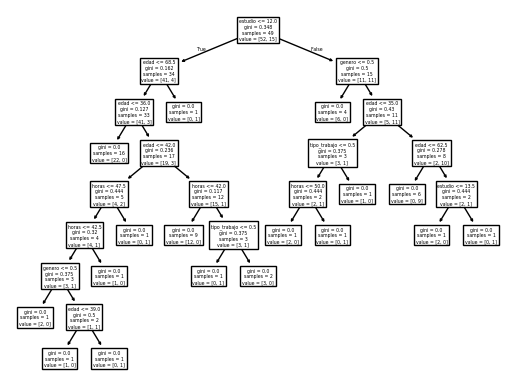

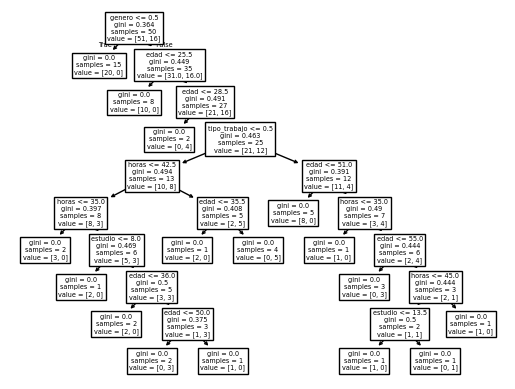

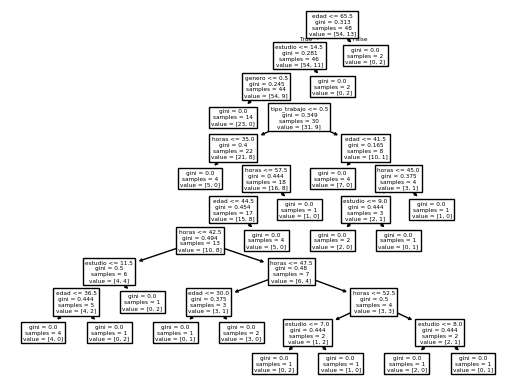

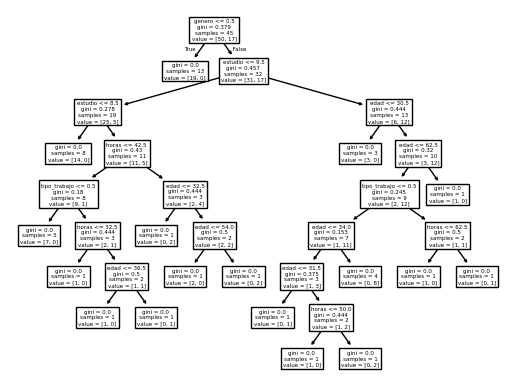

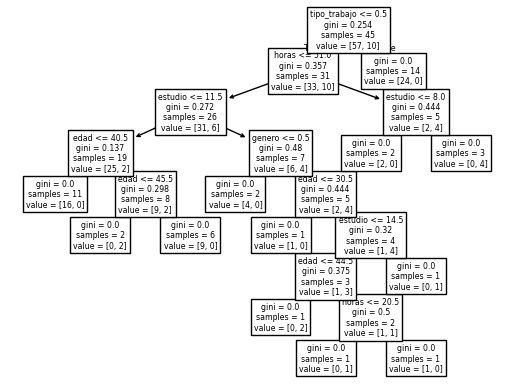

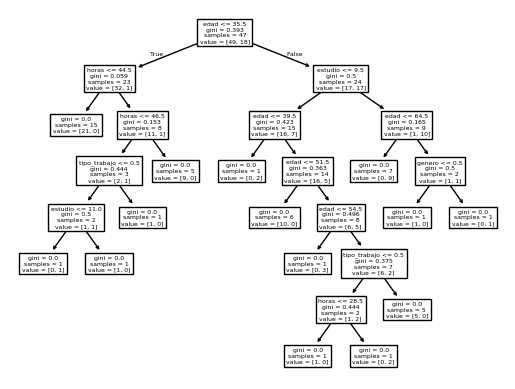

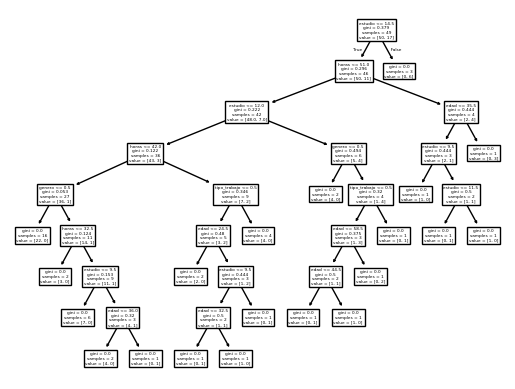

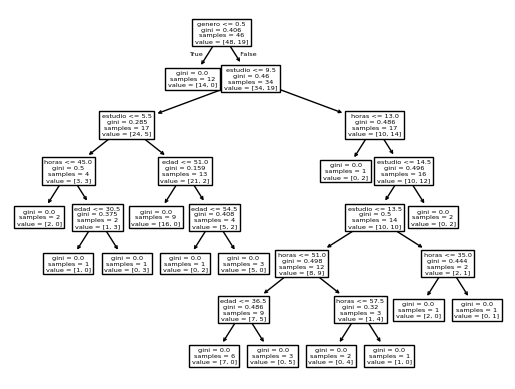

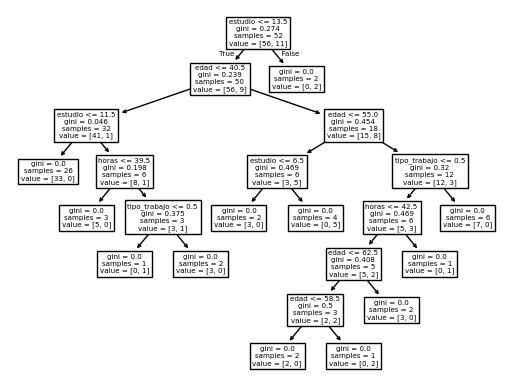

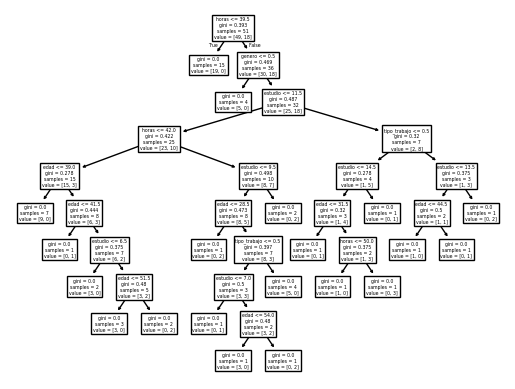

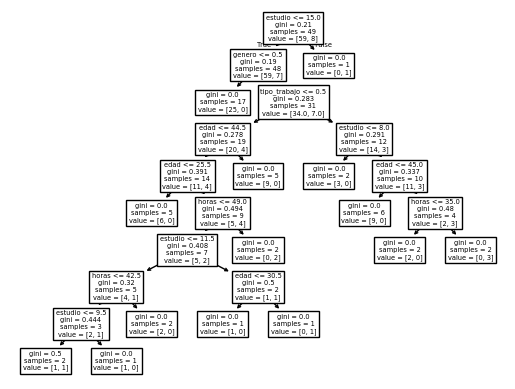

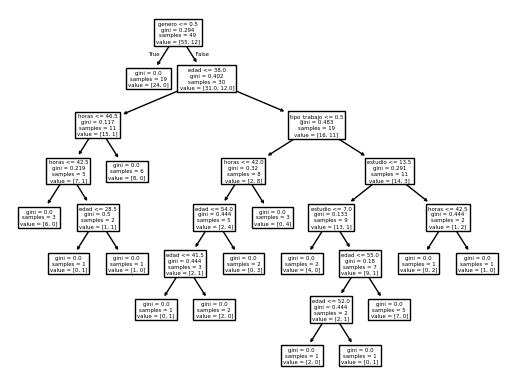

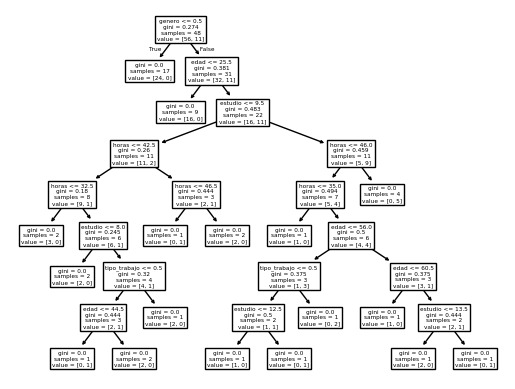

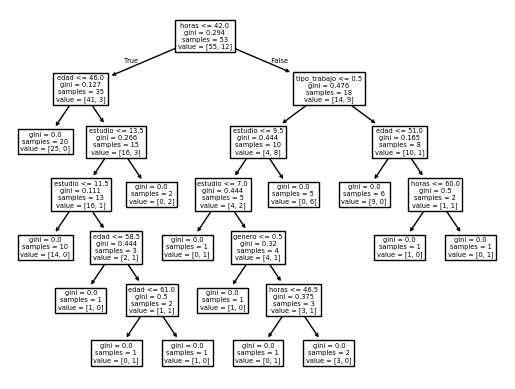

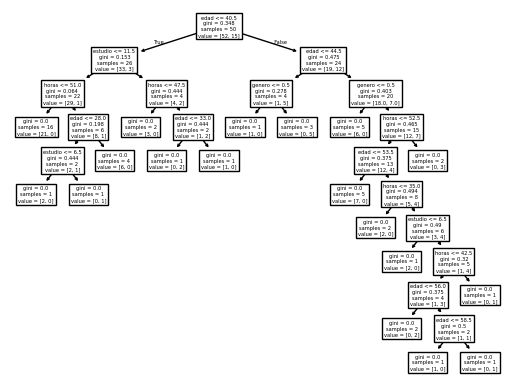

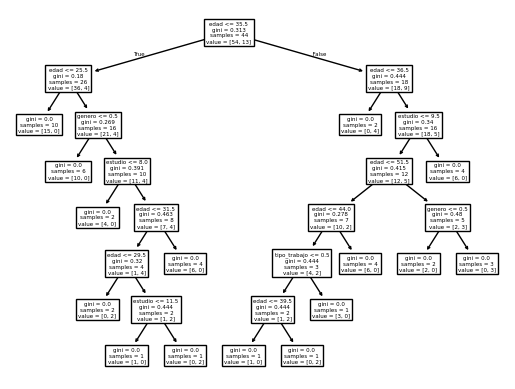

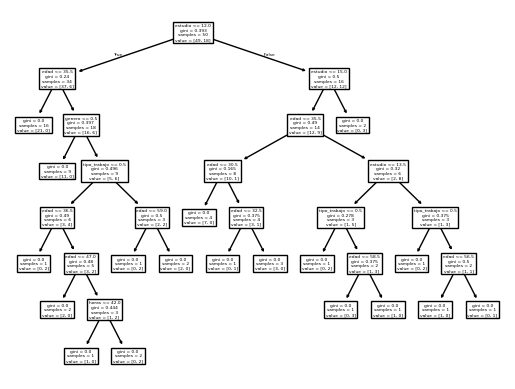

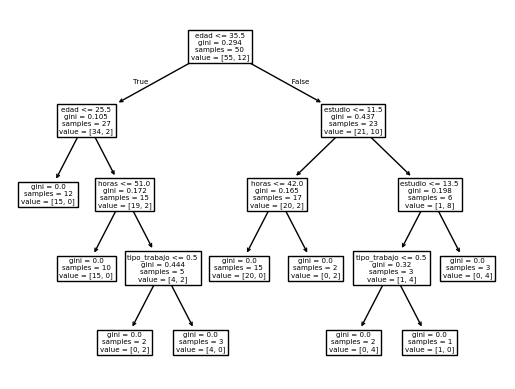

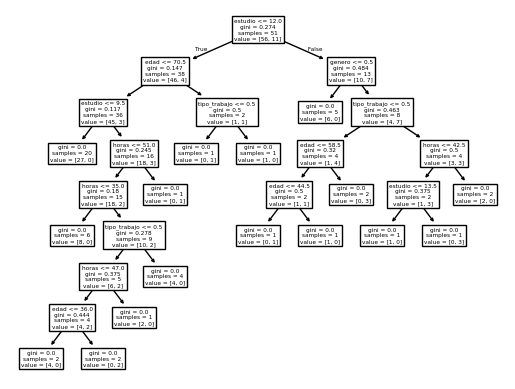

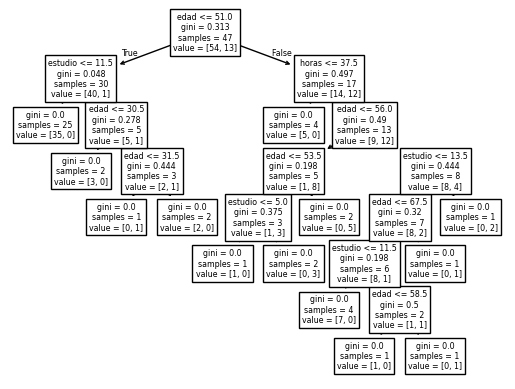

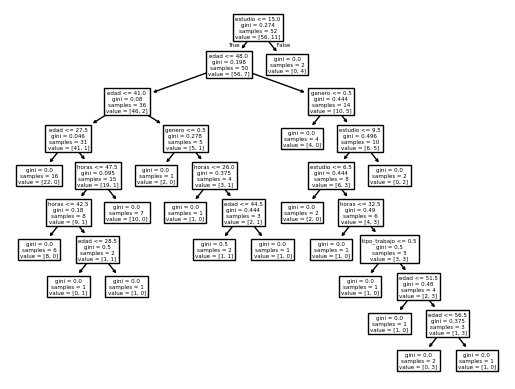

In [9]:
import matplotlib.pyplot as plt
from sklearn import tree

for arbol in bosque.estimators_:
    tree.plot_tree(arbol, feature_names=personas.columns[:-1])
    plt.show()

# "Joven haga su trabajo por favor"

###### 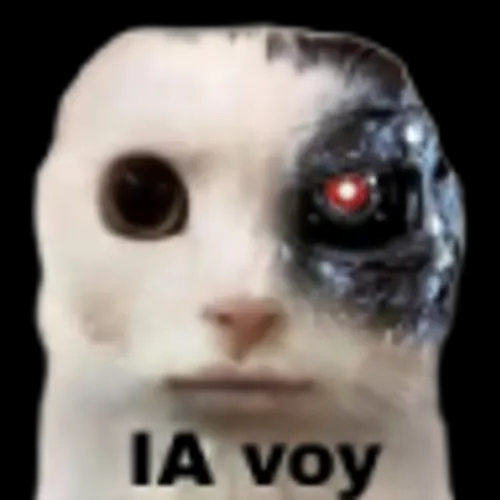

El chiste del gato que dice IA voy se refiere comunmente a utilizar inteligencia artificial para resolver los trabajos asignados de forma rapida.

La frase "Joven, haga su trabajo por favor" se suele usar seguido cuando un alumno no esta realizando trabajo en clase, por ello al utilizar la imagen del gato parcialmente robotico con la frase IA voy, se considera como un gesto comico.

*Explicacion generada por IA (Creanme)